# Synthetic Recovery Figure Workflow

This notebook rebuilds publication-style aggregate synthetic recovery figures from cached metric tables under `results/02_synthetic_analysis/synthetic_recovery/metrics`.


In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from utils.figures_utils import (
    RESULTS_DIR,
    SYNTHETIC_TOOL_COLORS,
    SYNTHETIC_TOOL_LABELS,
    SYNTHETIC_TOOL_ORDER,
    add_synthetic_tool_labels,
    apply_synthetic_tool_order,
    get_false_positive_beta_df,
    get_per_tool_summary_df,
    get_synthetic_aggregation_run_summary_df,
    get_synthetic_results,
    plot_false_positive_beta_violin,
    plot_synthetic_metric_bar,
    save_publication_figure,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
sns.set_theme(style="whitegrid")

OUT_DIR = RESULTS_DIR / "figures" / "03_synthetic_figures"
SAVE_FIGURES = True
SAVE_PDF = False
DPI = 300

TOOL_ORDER = SYNTHETIC_TOOL_ORDER.copy()
TOOL_LABELS = SYNTHETIC_TOOL_LABELS.copy()
TOOL_COLORS = SYNTHETIC_TOOL_COLORS.copy()

FIGSIZE_BP = (15, 4.5)
FIGSIZE_STRUCTURAL = (15, 4.5)
FIGSIZE_FALSE_BETA = (12, 6)
FIGSIZE_REGION = (15, 4.5)


def savefig_if_enabled(fig: plt.Figure, filename: str) -> None:
    if not SAVE_FIGURES:
        return
    save_publication_figure(
        fig,
        OUT_DIR,
        filename,
        dpi=DPI,
        save_pdf=SAVE_PDF,
    )


In [4]:
per_sample_df = get_synthetic_results().copy()
per_tool_summary_df = get_per_tool_summary_df().copy()
false_beta_df = get_false_positive_beta_df().copy()
run_summary_df = get_synthetic_aggregation_run_summary_df()

per_sample_df = add_synthetic_tool_labels(apply_synthetic_tool_order(per_sample_df))
per_tool_summary_df = add_synthetic_tool_labels(apply_synthetic_tool_order(per_tool_summary_df))
false_beta_df = add_synthetic_tool_labels(apply_synthetic_tool_order(false_beta_df))

print(f"Loaded {len(per_sample_df):,} per-sample metric rows")
print(f"Loaded {len(per_tool_summary_df):,} per-tool summary rows")
print(f"Loaded {len(false_beta_df):,} false-positive region beta rows")


Loaded 96 per-sample metric rows
Loaded 8 per-tool summary rows
Loaded 188,672 false-positive region beta rows


In [18]:
per_sample_df.columns

Index(['synthetic_sample_id', 'tool', 'boundary_tolerance_bp',
       'n_truth_regions', 'n_predicted_regions', 'bp_tp', 'bp_fp', 'bp_fn',
       'bp_tn', 'bp_precision', 'bp_recall', 'bp_f1', 'bp_jaccard',
       'bp_specificity', 'bp_accuracy', 'bp_per_region_recall_fraction',
       'bp_mabe', 'region_any_precision', 'region_any_recall', 'region_any_f1',
       'region_any_per_region_recall_fraction', 'region_any_mabe',
       'region_majority_precision', 'region_majority_recall',
       'region_majority_f1', 'region_majority_per_region_recall_fraction',
       'region_majority_mabe', 'region_super_majority_precision',
       'region_super_majority_recall', 'region_super_majority_f1',
       'region_super_majority_per_region_recall_fraction',
       'region_super_majority_mabe', 'fragmentation', 'absorption',
       'fragmentation_distance_from_1', 'absorption_distance_from_1',
       'avg_false_pmd_beta', 'mean_false_pmds_called', 'truth_bed',
       'synthetic_file', 'tool_label']

In [5]:
tool_coverage_df = (
    per_sample_df.groupby(["tool_label"], observed=True)
    .agg(
        n_samples=("synthetic_sample_id", "nunique"),
        n_metric_rows=("synthetic_sample_id", "size"),
    )
    .reset_index()
)

sample_coverage_df = (
    per_sample_df.groupby("synthetic_sample_id")
    .agg(n_tools=("tool", "nunique"))
    .reset_index()
    .sort_values(["n_tools", "synthetic_sample_id"], ascending=[False, True])
    .reset_index(drop=True)
)

display(tool_coverage_df)
display(sample_coverage_df.head())

if run_summary_df is not None:
    display(run_summary_df)


,tool_label,n_samples,n_metric_rows
0,MethylSeg WGBS,12,12
1,MethylSeg HM450K,12,12
2,MethylSeekR,12,12
3,DNMTools,12,12
4,DNMTools Array,12,12
5,DNMTools PMR,12,12
6,MMSeekR,12,12
7,MethylLasso,12,12


,synthetic_sample_id,n_tools
0,synthetic_GSM5652176_Adipocytes_Z000000T7_hg19...,8
1,synthetic_GSM5652250_Pancreas_Beta_Z00000452_h...,8
2,synthetic_GSM5652251_Pancreas_Beta_Z00000455_h...,8
3,synthetic_GSM5652348_Breast_Luminal_Epithelial...,8
4,synthetic_GSM5652349_Breast_Luminal_Epithelial...,8


,injected_manifest,tool_results_dir,metrics_dir,plots_dir,boundary_tolerance_bp,n_sample_procs,n_tool_procs,from_shards,n_metric_rows,n_expected_samples,n_called_samples
0,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,10000,1,1,True,96,12,12


## BP Recovery Metrics


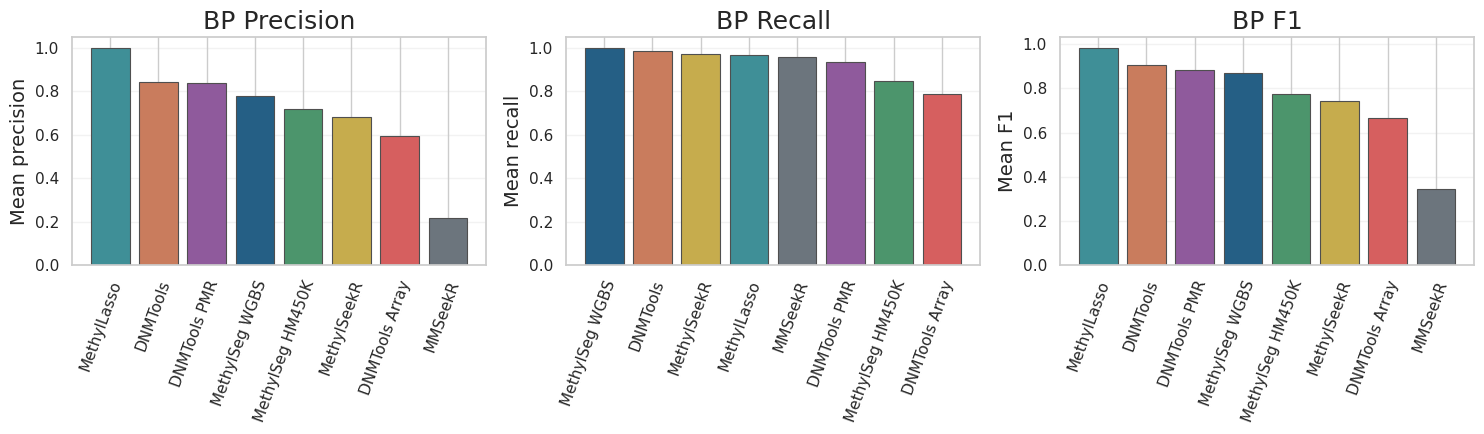

In [6]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_BP)

plot_synthetic_metric_bar(
    per_tool_summary_df,
    "bp_precision_mean",
    ax=axes[0],
    title="BP Precision",
    ylabel="Mean precision",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "bp_recall_mean",
    ax=axes[1],
    title="BP Recall",
    ylabel="Mean recall",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "bp_f1_mean",
    ax=axes[2],
    title="BP F1",
    ylabel="Mean F1",
)

fig.tight_layout()
savefig_if_enabled(fig, "bp_precision_recall_f1.png")
plt.show()


## Structural and False-Call Metrics


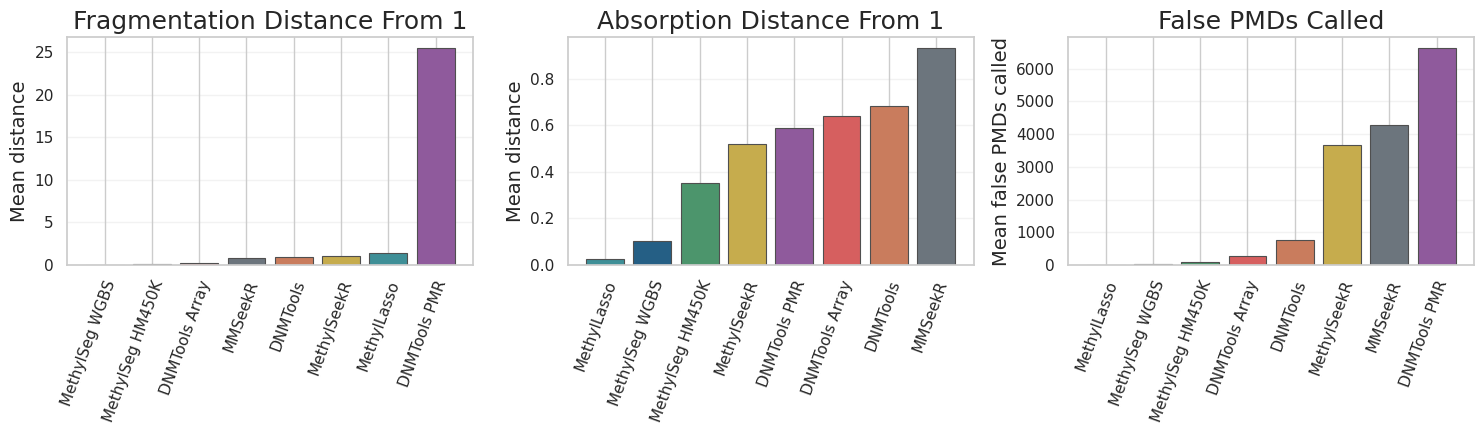

In [7]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_STRUCTURAL)

plot_synthetic_metric_bar(
    per_tool_summary_df,
    "fragmentation_distance_from_1_mean",
    ax=axes[0],
    title="Fragmentation Distance From 1",
    ylabel="Mean distance",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "absorption_distance_from_1_mean",
    ax=axes[1],
    title="Absorption Distance From 1",
    ylabel="Mean distance",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "mean_false_pmds_called_mean",
    ax=axes[2],
    title="False PMDs Called",
    ylabel="Mean false PMDs called",
)

fig.tight_layout()
savefig_if_enabled(fig, "fragmentation_absorption_false_calls.png")
plt.show()


## False-Positive Beta Distribution


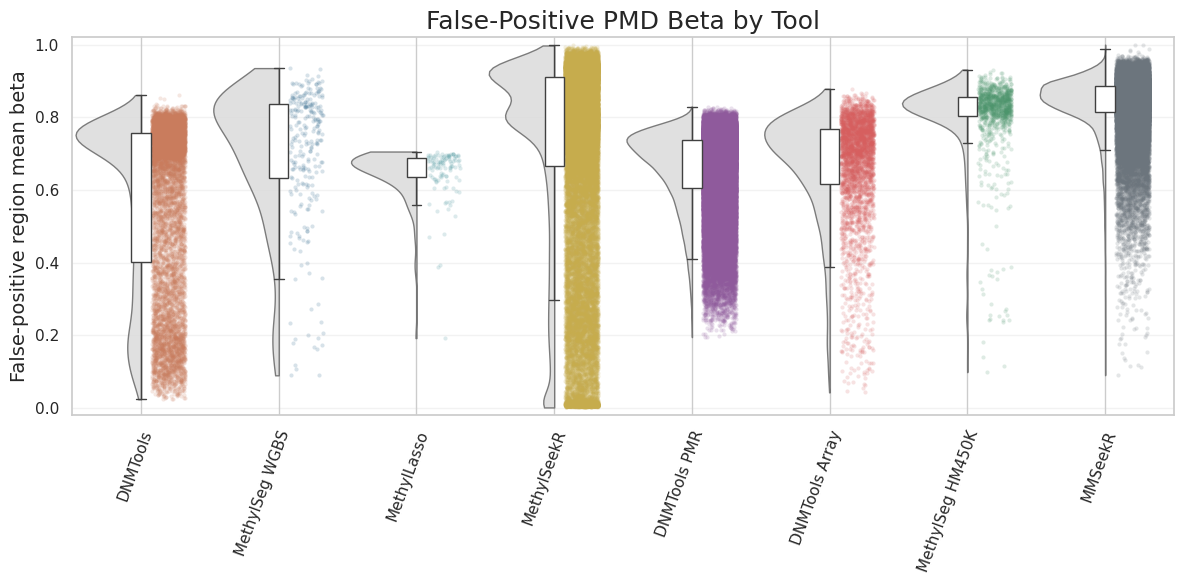

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE_FALSE_BETA)
plot_false_positive_beta_violin(
    false_beta_df,
    ax=ax,
    per_tool_summary_df=per_tool_summary_df,
    title="False-Positive PMD Beta by Tool",
    ylabel="False-positive region mean beta",
)

fig.tight_layout()
savefig_if_enabled(fig, "false_positive_beta_violin.png")
plt.show()


## Region-Level Recovery


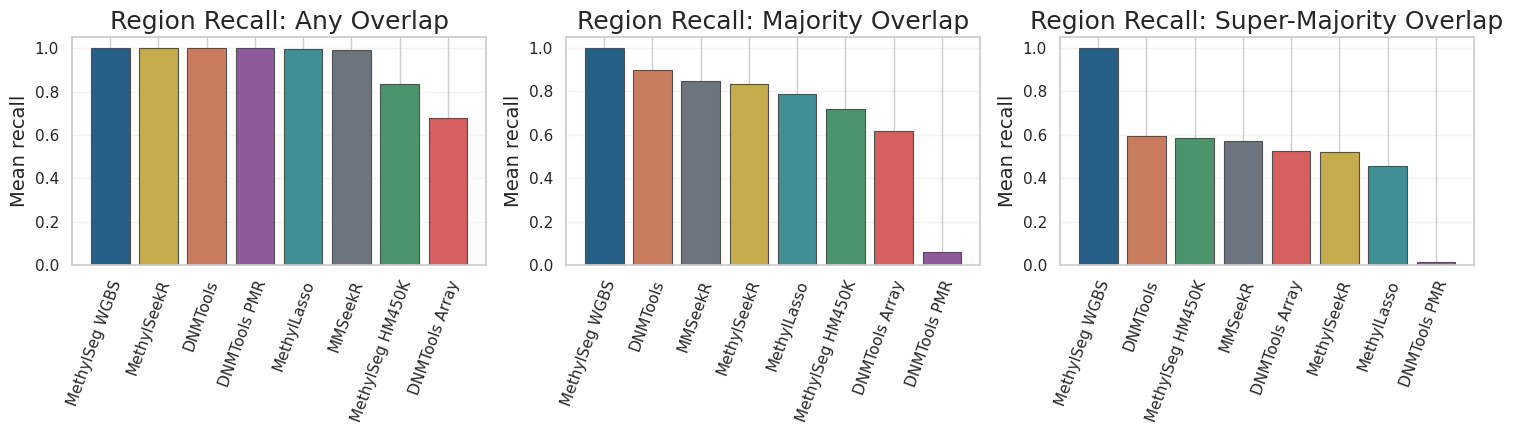

In [9]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_REGION)

plot_synthetic_metric_bar(
    per_tool_summary_df,
    "region_any_recall_mean",
    ax=axes[0],
    title="Region Recall: Any Overlap",
    ylabel="Mean recall",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "region_majority_recall_mean",
    ax=axes[1],
    title="Region Recall: Majority Overlap",
    ylabel="Mean recall",
)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "region_super_majority_recall_mean",
    ax=axes[2],
    title="Region Recall: Super-Majority Overlap",
    ylabel="Mean recall",
)

fig.tight_layout()
savefig_if_enabled(fig, "region_recall_thresholds.png")
plt.show()


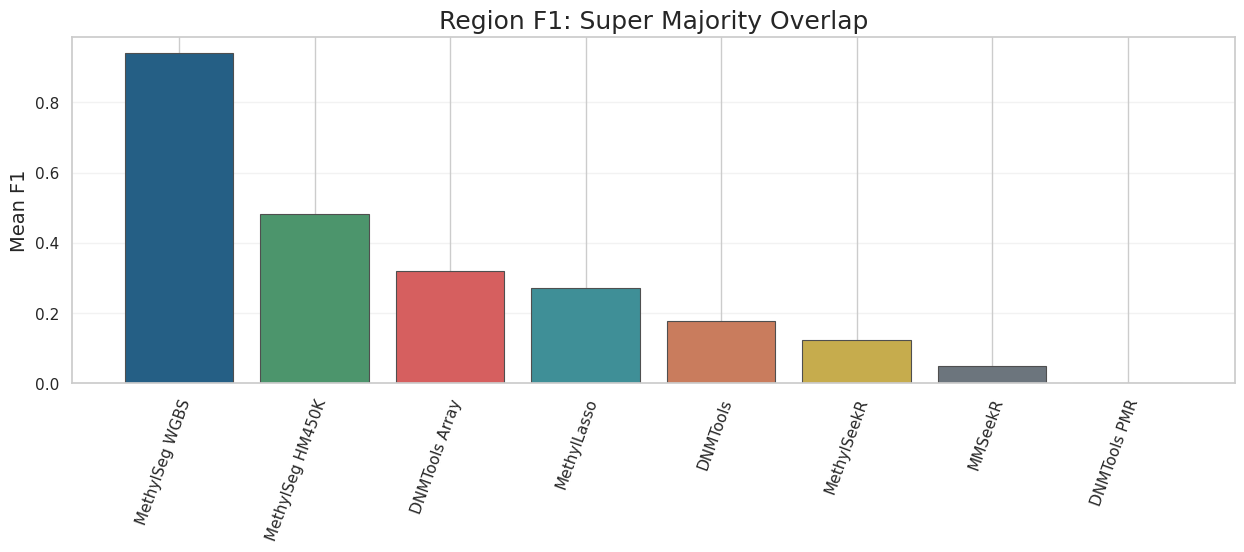

In [15]:
fig, axes = plt.subplots(1, 1, figsize=FIGSIZE_REGION)
plot_synthetic_metric_bar(
    per_tool_summary_df,
    "region_super_majority_f1_mean",
    ax=axes,
    title="Region F1: Super Majority Overlap",
    ylabel="Mean F1",
)
plt.show()